## Report

### 1. prediction table shape ✅
```
Models per ID: 1166 / 1166 / 1166 # each GSE has 1166 predictions.
``` 

### 2. max log2(prob/prior) dist ⚠️

||Human|Mouse|Note|
|--|--|--|--|
|mean max| ≈ 1.56|≈ 0.92|every GSE has a valid prediction & mouse prediction weaker than human prediction|
|min max| ≈ 0.0009||
|max < 1|1715 / 3395≈0.51|2809 / 4066≈0.69|many GSE metadata does not have a strong disease framing.|

### 3. anormalities ✅

```
mean > 1 : 0
std < 0.1 : 0
```

for each gse, there is no such:
* prob is high for all diseases
* prob is similar for all diseases

### 4. top gap = top 1 - top 2 ⚠️

||Human|Mouse|
|--|--|--|
|median gap| ≈ 0.05|≈ 0.045|
|gap < 0.1|2263|2927|

-> for most gse, top 1 and top 2 predictions are almost the same.
    - argmax unstable
    - top 1 highly uncertain

### Conclusion: focus on strong signal GSE only

* log2(prob/prior) > 1
* 且 gap > 0.2 ?

### 5. stable top 1 prediction w/ diff corpus（≈85%）

## Code
### Generate top1

In [27]:
# import pandas as pd

# def all_to_one(fp, output):
#     df = pd.read_csv(fp)
#     df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)

#     n_ids = df["ID"].nunique()
#     models_per_id = df.groupby("ID")["mondo_id"].nunique()
#     print("IDs:", n_ids)
#     print("Models per ID (min/median/max):",
#           int(models_per_id.min()),
#           float(models_per_id.median()),
#           int(models_per_id.max()))

#     df = df.sort_values(["ID", "log2(prob/prior)", "prob", "mondo_id"],
#                         ascending=[True, False, False, True],
#                         kind="mergesort")
#     top1 = df.groupby("ID", as_index=False).head(1)[
#         ["ID", "mondo_id", "prob", "log2(prob/prior)", "related_words"]
#     ].reset_index(drop=True)

#     top1.to_csv(output, index=False)
#     print("Saved:", output)

# all_to_one("results/meta/human_title_summary_preds.csv", "results/top1/human_title_summary_preds.csv")
# all_to_one("results/meta/human_title_summary_design_preds.csv", "results/top1/human_title_summary_design_preds.csv")
# all_to_one("results/meta/mouse_title_summary_preds.csv", "results/top1/mouse_title_summary_preds.csv")
# all_to_one("results/meta/mouse_title_summary_design_preds.csv", "results/top1/mouse_title_summary_design_preds.csv")

### All model

Human rows: (3958570, 6)
Mouse rows: (4740956, 6)

--- Human ---
IDs: 3395
Models per ID (min/median/max): 1166 1166.0 1166

--- Mouse ---
IDs: 4066
Models per ID (min/median/max): 1166 1166.0 1166

--- Human distribution ---
Max log2 mean: 1.5618509075861153
Max log2 min: 0.0008938698145071
Max log2 max: 6.736767467849661
IDs where max < 0: 0
IDs where max < 1: 1715

--- Mouse distribution ---
Max log2 mean: 0.9239166800047055
Max log2 min: 0.0008938698145071
Max log2 max: 5.562013940584957
IDs where max < 0: 0
IDs where max < 1: 2809

--- Human anomaly check ---
IDs with mean > 1: 0
IDs with std < 0.1: 0

--- Mouse anomaly check ---
IDs with mean > 1: 0
IDs with std < 0.1: 0


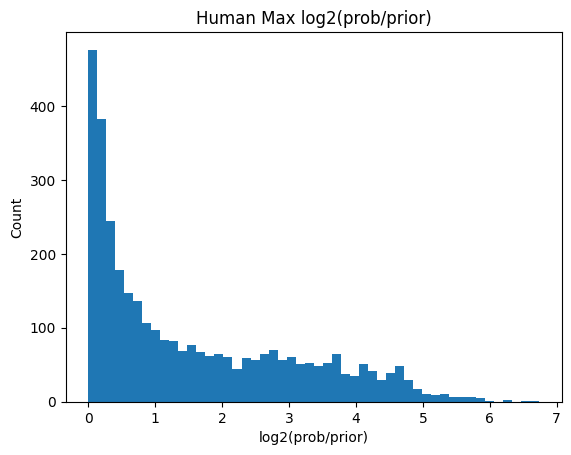

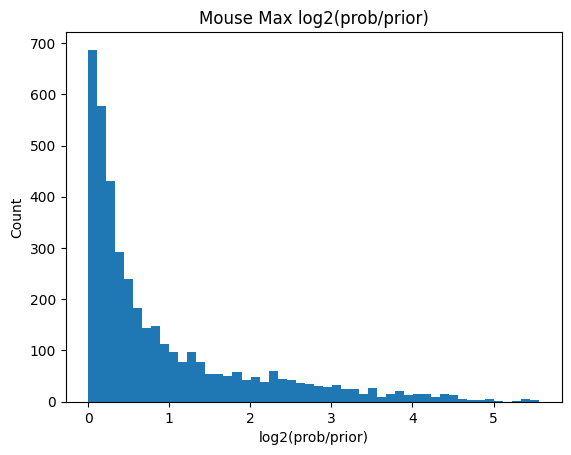


--- Human top gap ---
Mean gap: 0.10952153581069268
Median gap: 0.05048228103715857
IDs with gap < 0.1: 2263

--- Mouse top gap ---
Mean gap: 0.09224398137809624
Median gap: 0.0453929071715595
IDs with gap < 0.1: 2927


In [29]:
import pandas as pd
import numpy as np

def load_preds(fp):
    df = pd.read_csv(fp)
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)
    return df

human_preds = load_preds("results/meta/human_title_summary_preds.csv")
mouse_preds = load_preds("results/meta/mouse_title_summary_preds.csv")

print("Human rows:", human_preds.shape)
print("Mouse rows:", mouse_preds.shape)

def check_models_per_id(df, name):
    print(f"\n--- {name} ---")
    models_per_id = df.groupby("ID")["mondo_id"].nunique()
    print("IDs:", df["ID"].nunique())
    print("Models per ID (min/median/max):",
          int(models_per_id.min()),
          float(models_per_id.median()),
          int(models_per_id.max()))
    
    if models_per_id.min() != models_per_id.max():
        print("⚠ Some IDs missing models")

check_models_per_id(human_preds, "Human")
check_models_per_id(mouse_preds, "Mouse")

def distribution_check(df, name):
    print(f"\n--- {name} distribution ---")
    
    stats = df.groupby("ID")["log2(prob/prior)"].agg(["max", "mean", "std"])
    
    print("Max log2 mean:", stats["max"].mean())
    print("Max log2 min:", stats["max"].min())
    print("Max log2 max:", stats["max"].max())
    
    print("IDs where max < 0:", (stats["max"] < 0).sum())
    print("IDs where max < 1:", (stats["max"] < 1).sum())

distribution_check(human_preds, "Human")
distribution_check(mouse_preds, "Mouse")

def anomaly_check(df, name):
    print(f"\n--- {name} anomaly check ---")
    
    stats = df.groupby("ID")["log2(prob/prior)"].agg(["mean", "std"])
    
    print("IDs with mean > 1:", (stats["mean"] > 1).sum())
    print("IDs with std < 0.1:", (stats["std"] < 0.1).sum())

anomaly_check(human_preds, "Human")
anomaly_check(mouse_preds, "Mouse")

import matplotlib.pyplot as plt

def plot_max_distribution(df, name):
    max_scores = df.groupby("ID")["log2(prob/prior)"].max()
    
    plt.hist(max_scores, bins=50)
    plt.title(f"{name} Max log2(prob/prior)")
    plt.xlabel("log2(prob/prior)")
    plt.ylabel("Count")
    plt.show()

plot_max_distribution(human_preds, "Human")
plot_max_distribution(mouse_preds, "Mouse")

def top_gap_check(df, name):
    print(f"\n--- {name} top gap ---")
    
    df_sorted = df.sort_values(["ID", "log2(prob/prior)"], ascending=[True, False])
    top2 = df_sorted.groupby("ID").head(2)
    
    gap = top2.groupby("ID")["log2(prob/prior)"].diff().abs()
    gap = gap.dropna()
    
    print("Mean gap:", gap.mean())
    print("Median gap:", gap.median())
    print("IDs with gap < 0.1:", (gap < 0.1).sum())

top_gap_check(human_preds, "Human")
top_gap_check(mouse_preds, "Mouse")

### Filter & compare corpus

In [30]:
# human_ts  = pd.read_csv("results/top1/human_title_summary_preds.csv")
# human_tsd = pd.read_csv("results/top1/human_title_summary_design_preds.csv")
# mouse_ts  = pd.read_csv("results/top1/mouse_title_summary_preds.csv")
# mouse_tsd = pd.read_csv("results/top1/mouse_title_summary_design_preds.csv")

# def filter_strong_top1(df, threshold=1.5):
#     return df[df["log2(prob/prior)"] > threshold].copy()

# def compare_top1_strong_intersection(ts, tsd, name, threshold=1.5):
#     ts_s  = filter_strong_top1(ts, threshold)
#     tsd_s = filter_strong_top1(tsd, threshold)

#     merged = ts_s.merge(tsd_s, on="ID", suffixes=("_ts", "_tsd"))
#     total = len(merged)
#     same = (merged["mondo_id_ts"] == merged["mondo_id_tsd"]).sum()

#     print(f"\n--- {name} strong intersection (threshold={threshold}) ---")
#     print("Strong TS:", len(ts_s))
#     print("Strong TSD:", len(tsd_s))
#     print("Intersection:", total)
#     if total > 0:
#         print("Same top1:", same)
#         print("Agreement rate:", same / total)
#     else:
#         print("No IDs in intersection (threshold too strict?)")

# compare_top1_strong_intersection(human_ts, human_tsd, "Human", threshold=1.5)
# compare_top1_strong_intersection(mouse_ts, mouse_tsd, "Mouse", threshold=1.5)

# def compare_scores_strong_intersection(ts, tsd, name, threshold=1.5):
#     ts_s  = filter_strong_top1(ts, threshold)
#     tsd_s = filter_strong_top1(tsd, threshold)

#     merged = ts_s.merge(tsd_s, on="ID", suffixes=("_ts", "_tsd"))
#     if len(merged) == 0:
#         print(f"\n--- {name} ---\nNo IDs in intersection.")
#         return

#     diff = merged["log2(prob/prior)_tsd"] - merged["log2(prob/prior)_ts"]
#     print(f"\n--- {name} score diff on strong intersection (threshold={threshold}) ---")
#     print("Mean diff:", diff.mean())
#     print("Median diff:", diff.median())
#     print("Increased:", (diff > 0).sum())
#     print("Decreased:", (diff < 0).sum())

# compare_scores_strong_intersection(human_ts, human_tsd, "Human", threshold=1.5)
# compare_scores_strong_intersection(mouse_ts, mouse_tsd, "Mouse", threshold=1.5)

In [31]:
import os

os.makedirs("results", exist_ok=True)

TOP1_THRESHOLD = 1.0
GAP_THRESHOLD = 0.15

def add_top1_top2_gap(preds):
    df = preds.copy()
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)

    df = df.sort_values(
        ["ID", "log2(prob/prior)", "prob", "mondo_id"],
        ascending=[True, False, False, True],
        kind="mergesort"
    )

    top2 = df.groupby("ID").head(2).copy()
    top2["rank"] = top2.groupby("ID").cumcount() + 1

    scores = top2.pivot(
        index="ID",
        columns="rank",
        values="log2(prob/prior)"
    ).rename(columns={1: "top1_score", 2: "top2_score"})

    top1_info = top2[top2["rank"] == 1][
        ["ID", "mondo_id", "prob", "log2(prob/prior)", "related_words"]
    ].set_index("ID")

    out = top1_info.join(scores)
    out["top_gap"] = out["top1_score"] - out["top2_score"]

    return out.reset_index()

def filter_predictions(preds, top1_threshold=1.0, gap_threshold=0.15):
    top1 = add_top1_top2_gap(preds)

    filtered = top1[
        (top1["top1_score"] > top1_threshold) &
        (top1["top_gap"] > gap_threshold)
    ].copy()

    return filtered

human_final = filter_predictions(
    human_preds,
    top1_threshold=TOP1_THRESHOLD,
    gap_threshold=GAP_THRESHOLD
)

mouse_final = filter_predictions(
    mouse_preds,
    top1_threshold=TOP1_THRESHOLD,
    gap_threshold=GAP_THRESHOLD
)

human_final.to_csv("results/human_strong_preds.csv", index=False)
mouse_final.to_csv("results/mouse_strong_preds.csv", index=False)

print("Filter setting:")
print("top1_score >", TOP1_THRESHOLD)
print("top_gap >", GAP_THRESHOLD)

print("\nHuman saved:", human_final.shape)
print("Mouse saved:", mouse_final.shape)

human_final.head()

Filter setting:
top1_score > 1.0
top_gap > 0.15

Human saved: (546, 8)
Mouse saved: (438, 8)


,ID,mondo_id,prob,log2(prob/prior),related_words,top1_score,top2_score,top_gap
3,GSE100081,MONDO_0004995,0.176535,1.874996,"aortic,artery,coronary,disease,muscle,vascular",1.874996,1.607210,0.267785
26,GSE100562,MONDO_0005550,0.183282,1.343792,"falciparum,global,immune,individuals,infected,...",1.343792,0.752726,0.591066
30,GSE100624,MONDO_0004979,0.033235,2.278667,"asthma,inhaled,asthmatics,cd4,cd8,endotypes,pe...",2.278667,2.038425,0.240242
41,GSE100925,MONDO_0004989,0.447572,3.978430,"breast,chemotherapy,invasive,tumors",3.978430,3.472417,0.506013
55,GSE101480,MONDO_0018874,0.879091,4.857970,"acute,aml,compounds,inhibitors,leukemia,myeloi...",4.857970,4.233823,0.624147


### Quality check

In [32]:
import matplotlib.pyplot as plt

def get_top1_top2_gap(preds, species):
    df = preds.copy()
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)

    df = df.sort_values(
        ["ID", "log2(prob/prior)", "prob", "mondo_id"],
        ascending=[True, False, False, True],
        kind="mergesort"
    )

    top2 = df.groupby("ID").head(2).copy()
    top2["rank"] = top2.groupby("ID").cumcount() + 1

    score_wide = top2.pivot(
        index="ID",
        columns="rank",
        values="log2(prob/prior)"
    ).rename(columns={1: "top1_score", 2: "top2_score"})

    top1_info = top2[top2["rank"] == 1][
        ["ID", "mondo_id", "prob", "log2(prob/prior)", "related_words"]
    ].set_index("ID")

    out = top1_info.join(score_wide)
    out["top_gap"] = out["top1_score"] - out["top2_score"]
    out["species"] = species

    return out.reset_index()

human_qc = get_top1_top2_gap(human_preds, "human")
mouse_qc = get_top1_top2_gap(mouse_preds, "mouse")

human_qc.to_csv("results/human_top1_top2_gap_all.csv", index=False)
mouse_qc.to_csv("results/mouse_top1_top2_gap_all.csv", index=False)

print("Human all GSE:", human_qc.shape)
print("Mouse all GSE:", mouse_qc.shape)

display(human_qc.head())
display(mouse_qc.head())

Human all GSE: (3395, 9)
Mouse all GSE: (4066, 9)


,ID,mondo_id,prob,log2(prob/prior),related_words,top1_score,top2_score,top_gap,species
0,GSE100027,MONDO_0004989,0.053934,0.925587,"breast,cancer,cycle",0.925587,0.819984,0.105603,human
1,GSE100040,MONDO_0002271,0.003551,0.004945,ii,0.004945,0.000894,0.004052,human
2,GSE100075,MONDO_0021100,0.243358,1.816510,"breast,cancer,endocrine,estrogen,fulvestrant,l...",1.816510,1.816177,0.000333,human
3,GSE100081,MONDO_0004995,0.176535,1.874996,"aortic,artery,coronary,disease,muscle,vascular",1.874996,1.607210,0.267785,human
4,GSE100092,MONDO_0024882,0.010274,0.737961,"cancer,metastasis",0.737961,0.737926,0.000035,human


,ID,mondo_id,prob,log2(prob/prior),related_words,top1_score,top2_score,top_gap,species
0,GSE100035,MONDO_0021178,0.003200,0.423102,injury,0.423102,0.382377,0.040725,mouse
1,GSE100039,MONDO_0000314,0.009642,0.108923,months,0.108923,0.049221,0.059701,mouse
2,GSE100067,MONDO_0021166,0.121257,0.779340,"active,autoimmune,barrier,blood,inflammatory,m...",0.779340,0.608102,0.171237,mouse
3,GSE100070,MONDO_0001627,0.213176,2.510824,"ad,alzheimers,dementia,disease,diseases,memory...",2.510824,2.294787,0.216037,mouse
4,GSE100098,MONDO_0019052,0.017907,0.171449,"cells,deficiency,derived,fibroblasts,induced,m...",0.171449,0.165442,0.006008,mouse


In [33]:
def summarize_gap(df, species):
    print(f"\n{species}")
    print("Total GSE:", len(df))
    print(df[["top1_score", "top2_score", "top_gap"]].describe())

    print("\nTop1 > 1:", (df["top1_score"] > TOP1_THRESHOLD).sum())
    print("Gap > 0.15:", (df["top_gap"] > GAP_THRESHOLD).sum())
    print(
        "Top1 > 1 and gap > 0.15:",
        ((df["top1_score"] > TOP1_THRESHOLD) & (df["top_gap"] > GAP_THRESHOLD)).sum()
    )

summarize_gap(human_qc, "Human")
summarize_gap(mouse_qc, "Mouse")


Human
Total GSE: 3395
        top1_score   top2_score       top_gap
count  3395.000000  3395.000000  3.395000e+03
mean      1.561851     1.452329  1.095215e-01
std       1.504839     1.475470  1.545177e-01
min       0.000894    -0.000998  2.067867e-07
25%       0.268625     0.187303  1.156433e-02
50%       0.969955     0.838720  5.048228e-02
75%       2.674616     2.561168  1.410813e-01
max       6.736767     6.651830  1.455083e+00

Top1 > 1: 1680
Gap > 0.15: 800
Top1 > 1 and gap > 0.15: 546

Mouse
Total GSE: 4066
        top1_score   top2_score       top_gap
count  4066.000000  4066.000000  4.066000e+03
mean      0.923917     0.831673  9.224398e-02
std       1.073278     1.035741  1.393548e-01
min       0.000894    -0.000998  2.356771e-07
25%       0.172121     0.118305  1.368512e-02
50%       0.464835     0.369197  4.539291e-02
75%       1.302627     1.167923  1.135980e-01
max       5.562014     5.561775  2.052236e+00

Top1 > 1: 1257
Gap > 0.15: 755
Top1 > 1 and gap > 0.15: 438


In [34]:
# plt.figure(figsize=(7, 5))

# plt.hist(
#     human_qc["top_gap"],
#     bins=50,
#     alpha=0.6,
#     density=True,
#     label="Human"
# )

# plt.hist(
#     mouse_qc["top_gap"],
#     bins=50,
#     alpha=0.6,
#     density=True,
#     label="Mouse"
# )

# plt.axvline(GAP_THRESHOLD, linestyle="--", linewidth=2, label=f"gap = {GAP_THRESHOLD}")

# plt.xlabel("Top-1 score − Top-2 score")
# plt.ylabel("Density")
# plt.title("Distribution of Top-1 vs Top-2 Gap Before Filtering")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [35]:
# import numpy as np
# import matplotlib.pyplot as plt

# bins = np.linspace(0, 0.6, 31)

# plt.figure(figsize=(7, 5))

# plt.hist(
#     human_qc["top_gap"],
#     bins=bins,
#     weights=np.ones(len(human_qc)) / len(human_qc) * 100,
#     alpha=0.6,
#     label="Human"
# )

# plt.hist(
#     mouse_qc["top_gap"],
#     bins=bins,
#     weights=np.ones(len(mouse_qc)) / len(mouse_qc) * 100,
#     alpha=0.6,
#     label="Mouse"
# )

# plt.axvline(GAP_THRESHOLD, linestyle="--", linewidth=2, label=f"gap = {GAP_THRESHOLD}")

# plt.xlabel("Top-1 score − Top-2 score")
# plt.ylabel("Percentage of GSEs")
# plt.title("Top-1 vs Top-2 Gap Before Filtering")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [36]:
print("Human max gap:", human_qc["top_gap"].max())
print("Mouse max gap:", mouse_qc["top_gap"].max())

Human max gap: 1.4550828448491018
Mouse max gap: 2.0522360402951003


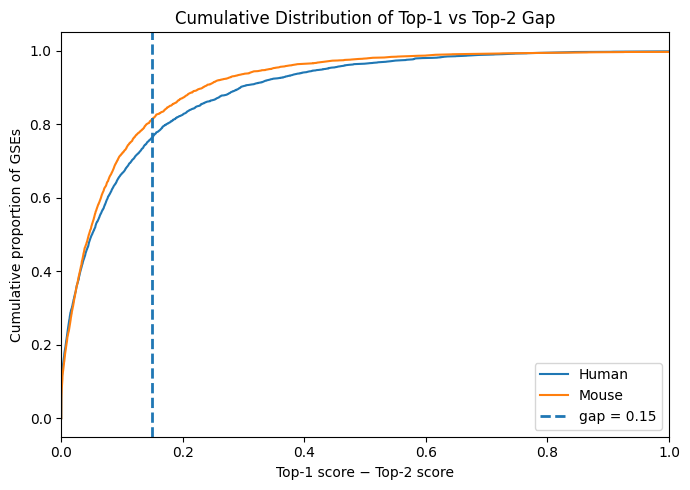

Saved: results/figures/top1_top2_cumulative_dist.png


In [37]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf(values, label):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label)

plt.figure(figsize=(7, 5))

plot_ecdf(human_qc["top_gap"], "Human")
plot_ecdf(mouse_qc["top_gap"], "Mouse")

plt.axvline(GAP_THRESHOLD, linestyle="--", linewidth=2, label=f"gap = {GAP_THRESHOLD}")

plt.xlim(0, 1)
plt.xlabel("Top-1 score − Top-2 score")
plt.ylabel("Cumulative proportion of GSEs")
plt.title("Cumulative Distribution of Top-1 vs Top-2 Gap")
plt.legend()
plt.tight_layout()
out_path = "results/figures/top1_top2_cumulative_dist.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

### Reproduce lineplot

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Parent → child chain in the cancer branch
cancer_chain = [
    "MONDO_0004992",
    "MONDO_0000621",
    "MONDO_0021138",
    "MONDO_0020076",
    "MONDO_0004643",
    "MONDO_0011996",
]

In [39]:
mouse_preds

,ID,prob,log2(prob/prior),related_words,model,mondo_id
0,GSE48962,0.488686,5.340032,"brain,disease,hd,htt,human,huntingtin,huntingt...",MONDO_0000167__preds,MONDO_0000167
1,GSE78272,0.278533,4.528970,"cag,control,disease,hd,htt,human,huntingtin,hu...",MONDO_0000167__preds,MONDO_0000167
2,GSE78274,0.278533,4.528970,"cag,control,disease,hd,htt,human,huntingtin,hu...",MONDO_0000167__preds,MONDO_0000167
3,GSE78270,0.278533,4.528970,"cag,control,disease,hd,htt,human,huntingtin,hu...",MONDO_0000167__preds,MONDO_0000167
4,GSE78273,0.278533,4.528970,"cag,control,disease,hd,htt,human,huntingtin,hu...",MONDO_0000167__preds,MONDO_0000167
...,...,...,...,...,...,...
4740951,GSE62571,0.000680,-0.001176,NaN,MONDO_0800089__preds,MONDO_0800089
4740952,GSE62573,0.000680,-0.001176,NaN,MONDO_0800089__preds,MONDO_0800089
4740953,GSE62621,0.000680,-0.001176,NaN,MONDO_0800089__preds,MONDO_0800089
4740954,GSE62633,0.000680,-0.001176,NaN,MONDO_0800089__preds,MONDO_0800089


In [40]:
def get_chain_scores(preds, chain):
    out = preds[preds["mondo_id"].isin(chain)].copy()

    out["level"] = out["mondo_id"].map({term: i for i, term in enumerate(chain)})
    out = out.sort_values(["ID", "level"])

    return out

mouse_chain_scores = get_chain_scores(mouse_preds, cancer_chain)

print("Rows:", mouse_chain_scores.shape)
print("GSEs:", mouse_chain_scores["ID"].nunique())

Rows: (24396, 7)
GSEs: 4066


In [41]:
THRESH = 1.0

# Convert to wide format: rows = GSE, columns = MONDO terms
mouse_chain_wide = mouse_chain_scores.pivot(
    index="ID",
    columns="mondo_id",
    values="log2(prob/prior)"
)

# Keep only GSEs that have scores for every term in the chain
mouse_chain_wide = mouse_chain_wide.dropna(subset=cancer_chain)

# Select GSEs that are confident at least somewhere in the chain
selected_ids = mouse_chain_wide[
    mouse_chain_wide[cancer_chain].max(axis=1) >= THRESH
].index

print("Selected GSEs:", len(selected_ids))

Selected GSEs: 106


In [42]:
THRESH = 1.0

selected_ids_all_levels = mouse_chain_wide[
    (mouse_chain_wide[cancer_chain] >= THRESH).all(axis=1)
].index

print("Selected GSEs confident at every level:", len(selected_ids_all_levels))

Selected GSEs confident at every level: 0


In [43]:
N = 12

top_ids = (
    mouse_chain_wide.loc[selected_ids, cancer_chain]
    .max(axis=1)
    .sort_values(ascending=False)
    .head(N)
    .index
)

plot_df = mouse_chain_scores[mouse_chain_scores["ID"].isin(top_ids)].copy()
plot_df["mondo_id"] = pd.Categorical(
    plot_df["mondo_id"],
    categories=cancer_chain,
    ordered=True
)
plot_df = plot_df.sort_values(["ID", "mondo_id"])

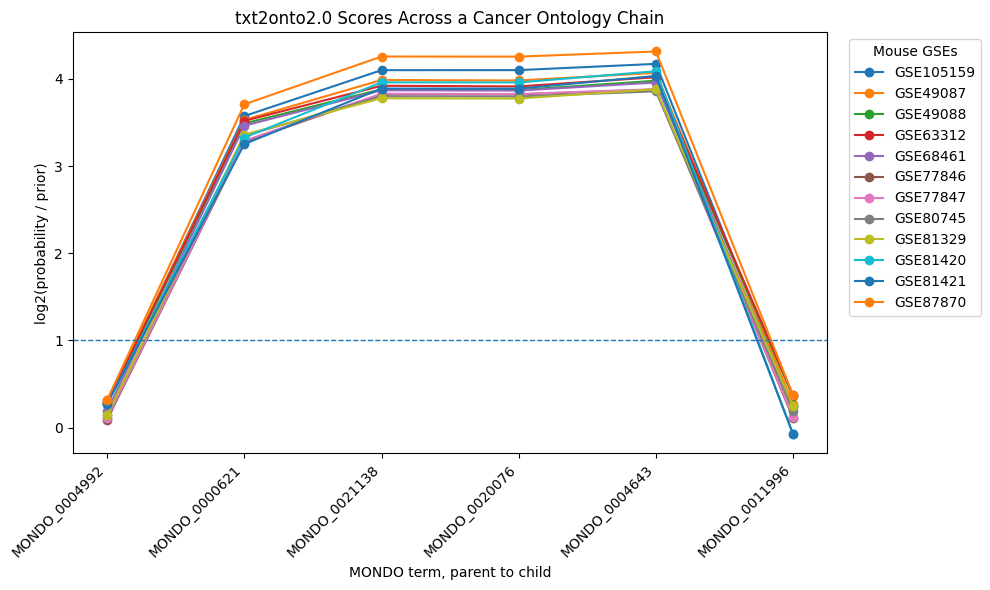

In [44]:
plt.figure(figsize=(10, 6))

for gse_id, sub in plot_df.groupby("ID"):
    plt.plot(
        sub["mondo_id"],
        sub["log2(prob/prior)"],
        marker="o",
        label=gse_id
    )

plt.axhline(THRESH, linestyle="--", linewidth=1)

plt.title("txt2onto2.0 Scores Across a Cancer Ontology Chain")
plt.xlabel("MONDO term, parent to child")
plt.ylabel("log2(probability / prior)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Mouse GSEs", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
out_path = "results/figures/mouse_cancer_chain_lineplot_2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()

### Try something new lineplot

In [45]:
from collections import defaultdict

edges = pd.read_csv("data/cancer_model_edges.csv")

parent_col = "parent"
child_col = "child"

children = defaultdict(set)
parents = defaultdict(set)

for _, row in edges.iterrows():
    parent = row[parent_col]
    child = row[child_col]
    children[parent].add(child)
    parents[child].add(parent)

print("Parents:", len(parents))
print("Children:", len(children))
print("Cancer root children:", children.get("MONDO_0004992", set()))

Parents: 260
Children: 174
Cancer root children: {'MONDO_0006290', 'MONDO_0020665', 'MONDO_0002149', 'MONDO_0006295', 'MONDO_0002516', 'MONDO_0000376', 'MONDO_0000653', 'MONDO_0006292', 'MONDO_0005872', 'MONDO_0005941', 'MONDO_0005089', 'MONDO_0000637', 'MONDO_0006517', 'MONDO_0002813', 'MONDO_0000621', 'MONDO_0002100', 'MONDO_0004993', 'MONDO_0024637', 'MONDO_0021069', 'MONDO_0005853', 'MONDO_0024881', 'MONDO_0005627', 'MONDO_0020663', 'MONDO_0020633', 'MONDO_0003274'}


In [46]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "MONDO_0004992"   # cancer
MIN_CHAIN_LEN = 6
MAX_DEPTH = 8
THRESH = 1.0
MIN_SIGNAL_GSE = 8

# 如果你已经有 parents，就构建 children
children = defaultdict(set)
for child, ps in parents.items():
    for p in ps:
        children[p].add(child)

model_terms = set(mouse_preds["mondo_id"].unique())

def get_model_covered_chains(root, children, model_terms, max_depth=8):
    chains = []

    def dfs(node, path):
        if len(path) >= max_depth:
            chains.append(path.copy())
            return

        next_children = sorted(children.get(node, []))
        next_children = [ch for ch in next_children if ch in model_terms]

        if not next_children:
            chains.append(path.copy())
            return

        for ch in next_children:
            dfs(ch, path + [ch])

    dfs(root, [root])
    return chains

candidate_chains = get_model_covered_chains(
    root=ROOT,
    children=children,
    model_terms=model_terms,
    max_depth=MAX_DEPTH
)

candidate_chains = [
    chain for chain in candidate_chains
    if len(chain) >= MIN_CHAIN_LEN
]

print("Chains with enough length and model coverage:", len(candidate_chains))

Chains with enough length and model coverage: 122


In [47]:
def count_signal_gse(preds, chain, threshold=1.0):
    chain_df = preds[preds["mondo_id"].isin(chain)].copy()

    wide = chain_df.pivot(
        index="ID",
        columns="mondo_id",
        values="log2(prob/prior)"
    )

    # 确保这个 GSE 对 chain 中每个 term 都有 score
    wide = wide.dropna(subset=chain)

    if wide.empty:
        return 0, wide

    signal_ids = wide[
        wide[chain].max(axis=1) >= threshold
    ].index

    return len(signal_ids), wide


valid_chains = []

for chain in candidate_chains:
    n_signal, wide = count_signal_gse(
        mouse_preds,
        chain,
        threshold=THRESH
    )

    if n_signal >= MIN_SIGNAL_GSE:
        valid_chains.append({
            "chain": chain,
            "length": len(chain),
            "n_signal_gse": n_signal
        })

chain_summary = pd.DataFrame(valid_chains)

chain_summary = chain_summary.sort_values(
    by=["length", "n_signal_gse"],
    ascending=[False, False]
)

print("Valid chains:", len(chain_summary))
chain_summary.head(10)

Valid chains: 121


,chain,length,n_signal_gse
72,"[MONDO_0004992, MONDO_0004993, MONDO_0006181, ...",8,111
73,"[MONDO_0004992, MONDO_0004993, MONDO_0006181, ...",8,111
22,"[MONDO_0004992, MONDO_0002516, MONDO_0002691, ...",8,104
23,"[MONDO_0004992, MONDO_0002516, MONDO_0002691, ...",8,104
24,"[MONDO_0004992, MONDO_0002516, MONDO_0002691, ...",8,104
25,"[MONDO_0004992, MONDO_0002516, MONDO_0002691, ...",8,104
26,"[MONDO_0004992, MONDO_0002516, MONDO_0002691, ...",8,104
4,"[MONDO_0004992, MONDO_0000621, MONDO_0021138, ...",8,102
6,"[MONDO_0004992, MONDO_0000637, MONDO_0002129, ...",8,98
7,"[MONDO_0004992, MONDO_0000637, MONDO_0002129, ...",8,98


In [48]:
plot_chain = chain_summary.iloc[2]["chain"]

print("Selected chain:")
for i, term in enumerate(plot_chain):
    print(f"Level {i}: {term}")

# plot_chain = plot_chain[:6]

Selected chain:
Level 0: MONDO_0004992
Level 1: MONDO_0002516
Level 2: MONDO_0002691
Level 3: MONDO_0003060
Level 4: MONDO_0003059
Level 5: MONDO_0005496
Level 6: MONDO_0003090
Level 7: MONDO_0002665


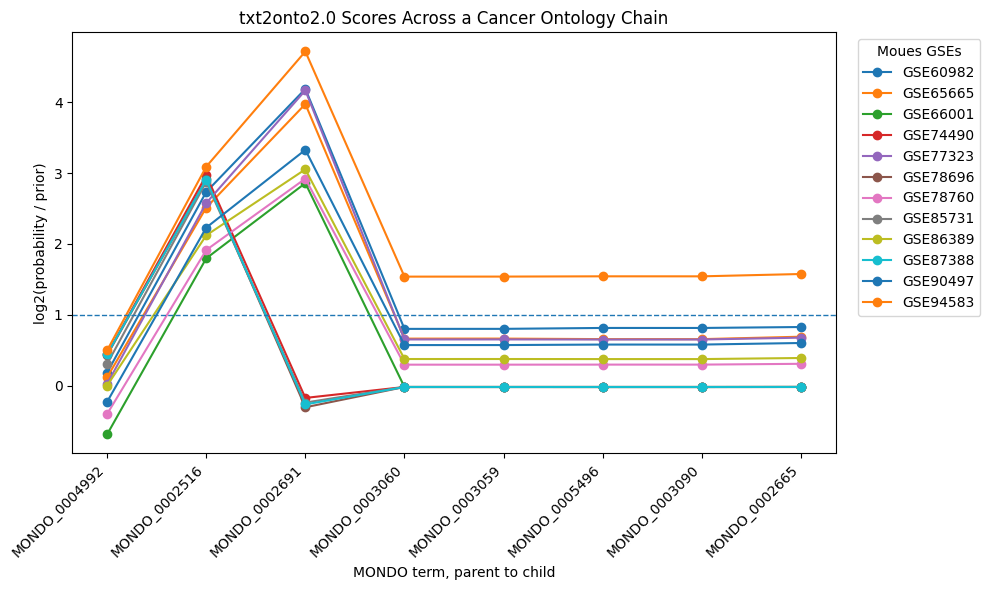

In [49]:
N = 12

chain_df = mouse_preds[mouse_preds["mondo_id"].isin(plot_chain)].copy()

chain_wide = chain_df.pivot(
    index="ID",
    columns="mondo_id",
    values="log2(prob/prior)"
)

chain_wide = chain_wide.dropna(subset=plot_chain)

selected_ids = chain_wide[
    chain_wide[plot_chain].max(axis=1) >= THRESH
].index

top_ids = (
    chain_wide.loc[selected_ids, plot_chain]
    .max(axis=1)
    .sort_values(ascending=False)
    .head(N)
    .index
)

plot_df = chain_df[chain_df["ID"].isin(top_ids)].copy()
plot_df["mondo_id"] = pd.Categorical(
    plot_df["mondo_id"],
    categories=plot_chain,
    ordered=True
)
plot_df = plot_df.sort_values(["ID", "mondo_id"])

plt.figure(figsize=(10, 6))

for gse_id, sub in plot_df.groupby("ID"):
    plt.plot(
        sub["mondo_id"],
        sub["log2(prob/prior)"],
        marker="o",
        label=gse_id
    )

plt.axhline(THRESH, linestyle="--", linewidth=1)

plt.title("txt2onto2.0 Scores Across a Cancer Ontology Chain")
plt.xlabel("MONDO term, parent to child")
plt.ylabel("log2(probability / prior)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Moues GSEs", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

out_path = "results/figures/mouse_cancer_chain_lineplot_1.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()

In [50]:
# root vs deepest child
root_term = plot_chain[0]
leaf_term = plot_chain[-1]

obs = chain_wide.loc[top_ids, plot_chain].copy()

print("Mean root score:", obs[root_term].mean())
print("Mean leaf score:", obs[leaf_term].mean())
print("Mean leaf - root:", (obs[leaf_term] - obs[root_term]).mean())

# 每个 GSE peak 在哪一层
peak_terms = obs.idxmax(axis=1)
peak_levels = peak_terms.map({term: i for i, term in enumerate(plot_chain)})

print("\nPeak level counts:")
print(peak_levels.value_counts().sort_index())

Mean root score: 0.0945332320472559
Mean leaf score: 0.4146870532273323
Mean leaf - root: 0.3201538211800764

Peak level counts:
1    4
2    8
Name: count, dtype: int64


### pattern for human gse

In [61]:
chain_levels = pd.DataFrame({
    "mondo_id": chain,
    "level": range(len(chain))
})

chain_terms = cancer_chain

In [62]:
import pandas as pd
import numpy as np

TOP1_THRESHOLD = 1.0
GAP_THRESHOLD = 0.15

def get_chain_peak_summary(preds, species, chain_terms):
    df = preds.copy()
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)

    chain_df = df[df["mondo_id"].isin(chain_terms)].copy()
    chain_df["chain_level"] = chain_df["mondo_id"].map(
        {term: i for i, term in enumerate(chain_terms)}
    )

    # one row per GSE × chain term
    wide = chain_df.pivot_table(
        index="ID",
        columns="chain_level",
        values="log2(prob/prior)",
        aggfunc="max"
    )

    # keep GSEs that have scores for all chain terms
    wide = wide.dropna()

    values = wide.values

    peak_level = values.argmax(axis=1)
    peak_score = values.max(axis=1)

    sorted_values = np.sort(values, axis=1)
    second_score = sorted_values[:, -2]
    chain_gap = peak_score - second_score

    out = pd.DataFrame({
        "ID": wide.index,
        "species": species,
        "peak_level": peak_level,
        "peak_term": [chain_terms[i] for i in peak_level],
        "peak_score": peak_score,
        "second_score": second_score,
        "chain_gap": chain_gap
    })

    out["peak_at_root"] = out["peak_level"] == 0
    out["peak_at_terminal"] = out["peak_level"] == len(chain_terms) - 1
    out["peak_intermediate"] = ~out["peak_at_root"] & ~out["peak_at_terminal"]

    out["strong_peak"] = out["peak_score"] > TOP1_THRESHOLD
    out["clear_peak"] = out["chain_gap"] >= GAP_THRESHOLD
    out["successful_case"] = (
        out["peak_intermediate"] &
        out["strong_peak"] &
        out["clear_peak"]
    )

    return out

human_chain_qc = get_chain_peak_summary(human_preds, "human", chain_terms)
mouse_chain_qc = get_chain_peak_summary(mouse_preds, "mouse", chain_terms)

chain_qc = pd.concat([human_chain_qc, mouse_chain_qc], ignore_index=True)

chain_qc.head()

,ID,species,peak_level,peak_term,peak_score,second_score,chain_gap,peak_at_root,peak_at_terminal,peak_intermediate,strong_peak,clear_peak,successful_case
0,GSE100027,human,5,MONDO_0011996,-0.096508,-0.211060,0.114552,False,True,False,False,False,False
1,GSE100040,human,5,MONDO_0011996,-0.013484,-0.391662,0.378178,False,True,False,False,True,False
2,GSE100075,human,0,MONDO_0004992,0.035405,0.002842,0.032563,True,False,False,False,False,False
3,GSE100081,human,5,MONDO_0011996,0.169910,-0.375674,0.545584,False,True,False,False,True,False
4,GSE100092,human,0,MONDO_0004992,0.038224,-0.110785,0.149010,True,False,False,False,False,False


In [63]:
summary = (
    chain_qc
    .groupby("species")
    .agg(
        n_gse=("ID", "count"),
        mean_peak_score=("peak_score", "mean"),
        median_peak_score=("peak_score", "median"),
        mean_chain_gap=("chain_gap", "mean"),
        median_chain_gap=("chain_gap", "median"),
        pct_peak_intermediate=("peak_intermediate", "mean"),
        pct_strong_peak=("strong_peak", "mean"),
        pct_clear_peak=("clear_peak", "mean"),
        pct_successful_case=("successful_case", "mean"),
        pct_peak_at_root=("peak_at_root", "mean"),
        pct_peak_at_terminal=("peak_at_terminal", "mean")
    )
    .reset_index()
)

percent_cols = [
    "pct_peak_intermediate",
    "pct_strong_peak",
    "pct_clear_peak",
    "pct_successful_case",
    "pct_peak_at_root",
    "pct_peak_at_terminal"
]

summary[percent_cols] = summary[percent_cols] * 100

summary

,species,n_gse,mean_peak_score,median_peak_score,mean_chain_gap,median_chain_gap,pct_peak_intermediate,pct_strong_peak,pct_clear_peak,pct_successful_case,pct_peak_at_root,pct_peak_at_terminal
0,human,3395,0.160506,0.012080,0.386915,0.396027,7.746686,3.946981,84.447717,0.883652,15.463918,76.789396
1,mouse,4066,0.070030,-0.036715,0.383056,0.411438,8.091490,2.606985,87.358583,0.664043,2.606985,89.301525


In [64]:
peak_level_counts = (
    chain_qc
    .groupby(["species", "peak_level"])
    .size()
    .reset_index(name="count")
)

peak_level_counts["percent"] = (
    peak_level_counts["count"] /
    peak_level_counts.groupby("species")["count"].transform("sum") * 100
)

peak_level_counts

,species,peak_level,count,percent
0,human,0,525,15.463918
1,human,1,129,3.799705
2,human,2,51,1.502209
3,human,3,26,0.765832
4,human,4,57,1.678940
5,human,5,2607,76.789396
6,mouse,0,106,2.606985
7,mouse,1,179,4.402361
8,mouse,2,50,1.229710
9,mouse,3,42,1.032956


In [67]:
# minimum

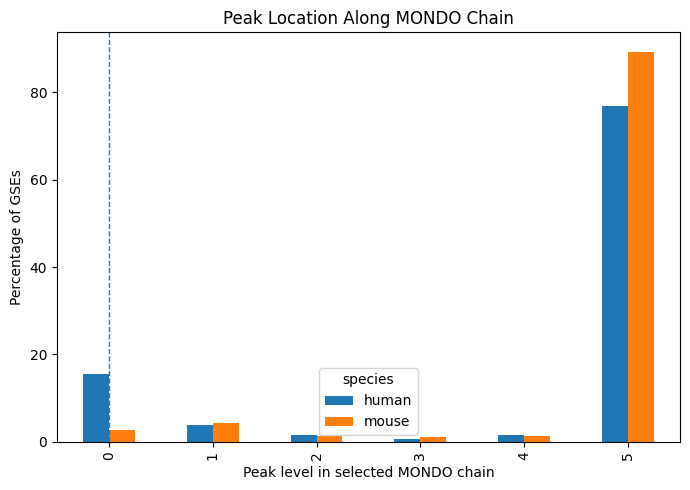

In [65]:
import matplotlib.pyplot as plt

pivot = peak_level_counts.pivot(
    index="peak_level",
    columns="species",
    values="percent"
).fillna(0)

pivot.plot(kind="bar", figsize=(7, 5))

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Peak level in selected MONDO chain")
plt.ylabel("Percentage of GSEs")
plt.title("Peak Location Along MONDO Chain")
plt.tight_layout()
plt.show()

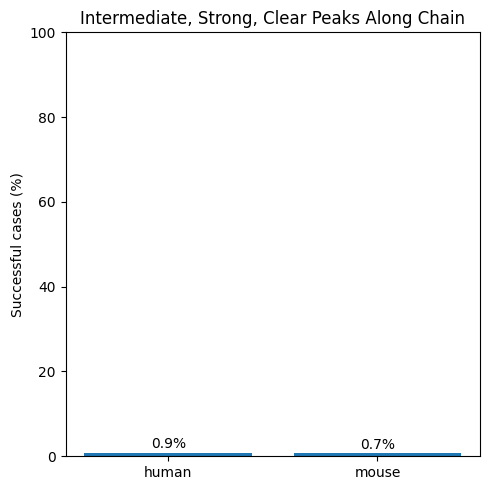

In [66]:
success_summary = (
    chain_qc
    .groupby("species")["successful_case"]
    .mean()
    .mul(100)
    .reset_index(name="successful_case_percent")
)

plt.figure(figsize=(5, 5))

plt.bar(
    success_summary["species"],
    success_summary["successful_case_percent"]
)

plt.ylabel("Successful cases (%)")
plt.title("Intermediate, Strong, Clear Peaks Along Chain")

for i, v in enumerate(success_summary["successful_case_percent"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()